In [1]:
import os
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stat
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.chdir('pilot_data')

In [3]:
os.listdir()

['650b03136ab3d4c832d98b71.txt',
 '66465c850d9a3e177f2649fa.txt',
 '668dbda2d3b329f1ea92a78a.txt',
 '6a0a200efdf95c93dce00159.txt',
 '6a12af25a82c000c54c955c9.txt']

In [4]:
experiment_df = pd.DataFrame()
demographic_df = pd.DataFrame()
for id in os.listdir():
    data = json.load(open(id))          
    experiment  = pd.DataFrame(data["trials"])
    demographic = pd.DataFrame([data["demographics"]])
    experiment_df = pd.concat([experiment_df, experiment], ignore_index=True)
    demographic_df = pd.concat([demographic_df, demographic], ignore_index=True)

In [5]:
experiment_df.to_csv('../pilot_experiment_data.csv', index=False)

# survey

In [6]:
demographic_df[['coverstory', 'sound_awareness', 'speed_awareness', 'subject_id']]

,coverstory,sound_awareness,speed_awareness,subject_id
0,children,"Yes, sometimes louder and sometimes softer",Yes,650b03136ab3d4c832d98b71
1,children,"Yes, sometimes louder and sometimes softer",Yes,66465c850d9a3e177f2649fa
2,children,"Yes, sometimes louder and sometimes softer",Yes,668dbda2d3b329f1ea92a78a
3,children,"Yes, sometimes louder and sometimes softer",No,6a0a200efdf95c93dce00159
4,children,No change noticed,Yes,6a12af25a82c000c54c955c9


# main analysis - across sound conditions

In [7]:
experiment_df.head()

,id,trial_number,trialID,soundCondition,chargeSpeed,leftColor,ISI_ms,repetition,response,is_fight,response_rt,confidence,confidence_rt,subject_id
0,650b03136ab3d4c832d98b71,1,4a2adf87-0f15-4bc0-9837-899addfb179c,higher,2.75,black,512.5,4,fight,1,162679,8.666667,1783,650b03136ab3d4c832d98b71
1,650b03136ab3d4c832d98b71,2,2c174300-1111-477c-b605-e34e6031cd26,same,6.50,grey,478.6,6,fight,1,716,22.833333,1180,650b03136ab3d4c832d98b71
2,650b03136ab3d4c832d98b71,3,e838dadb-c02f-4273-ae93-210720dcd06c,lower,1.50,grey,475.9,9,play,0,564,40.000000,2076,650b03136ab3d4c832d98b71
3,650b03136ab3d4c832d98b71,4,50f23891-0e3f-40d3-8bcb-a5bcfcec1987,same,7.75,grey,481.2,5,fight,1,650,32.166667,2285,650b03136ab3d4c832d98b71
4,650b03136ab3d4c832d98b71,5,debe6245-13a4-4a31-b28a-e7b25ce8fa93,lower,6.50,grey,478.6,8,fight,1,834,26.333333,1860,650b03136ab3d4c832d98b71


In [8]:
experiment_df.groupby(['id', 'soundCondition', 'chargeSpeed']).count()

trial_number  trialID  \
id                       soundCondition chargeSpeed                          
650b03136ab3d4c832d98b71 higher         1.50                    6        6   
                                        2.75                    6        6   
                                        4.00                   10       10   
                                        5.25                   10       10   
                                        6.50                   10       10   
...                                                           ...      ...   
6a12af25a82c000c54c955c9 same           4.00                   10       10   
                                        5.25                   10       10   
                                        6.50                   10       10   
                                        7.75                    6        6   
                                        9.00                    6        6   

                                                     leftColor  ISI_ms  \
id                       soundCondition chargeSpeed                      
650b03136ab3d4c832d98b71 higher         1.50                 6       6   
                                        2.75                 6       6   
                                        4.00                10      10   
                                        5.25                10      10   
                                        6.50                10      10   
...                                                        ...     ...   
6a12af25a82c000c54c955c9 same           4.00                10      10   
                                        5.25                10      10   
                                        6.50                10      10   
                                        7.75                 6       6   
                                        9.00                 6       6   

                                                     repetition  response  \
id                       soundCondition chargeSpeed                         
650b03136ab3d4c832d98b71 higher         1.50                  6         6   
                                        2.75                  6         6   
                                        4.00                 10        10   
                                        5.25                 10        10   
                                        6.50                 10        10   
...                                                         ...       ...   
6a12af25a82c000c54c955c9 same           4.00                 10        10   
                                        5.25                 10        10   
                                        6.50                 10        10   
                                        7.75                  6         6   
                                        9.00                  6         6   

                                                     is_fight  response_rt  \
id                       soundCondition chargeSpeed                          
650b03136ab3d4c832d98b71 higher         1.50                6            6   
                                        2.75                6            6   
                                        4.00               10           10   
                                        5.25               10           10   
                                        6.50               10           10   
...                                                       ...          ...   
6a12af25a82c000c54c955c9 same           4.00               10           10   
                                        5.25               10           10   
                                        6.50               10           10   
                                        7.75                6            6   
                                        9.00                6            6   

                                                     confi

In [9]:
ids = experiment_df['id'].unique()
ids

array(['650b03136ab3d4c832d98b71', '66465c850d9a3e177f2649fa',
       '668dbda2d3b329f1ea92a78a', '6a0a200efdf95c93dce00159',
       '6a12af25a82c000c54c955c9'], dtype=object)

## judgement

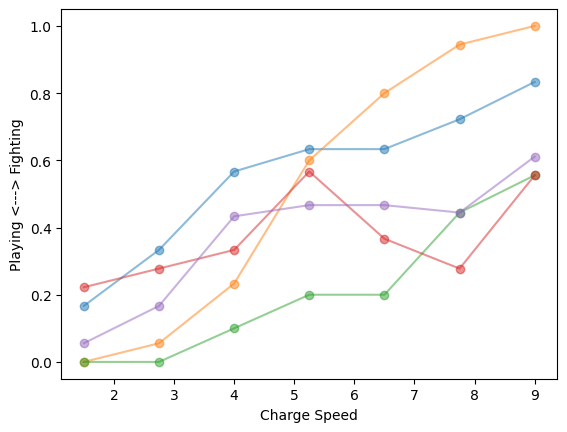

In [10]:
for id in ids:
    df = experiment_df[experiment_df['id'] == id]
    mean_rating_per_speed = pd.DataFrame(df.groupby('chargeSpeed')['is_fight'].mean().reset_index())
    plt.plot(mean_rating_per_speed['chargeSpeed'], mean_rating_per_speed['is_fight'], marker='o', alpha=0.5)
    plt.ylim(-0.05, 1.05)
    plt.xlabel('Charge Speed')
    plt.ylabel('Playing <---> Fighting')

Text(0, 0.5, 'Playing <---> Fighting')

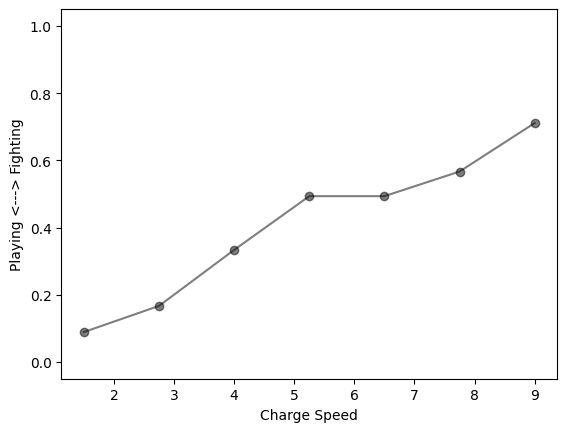

In [11]:
mean_judgement = pd.DataFrame(experiment_df.groupby('chargeSpeed')['is_fight'].mean().reset_index())
plt.plot(mean_judgement['chargeSpeed'], mean_judgement['is_fight'], color='black', marker='o', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.xlabel('Charge Speed')
plt.ylabel('Playing <---> Fighting')

In [12]:
id_mean = experiment_df.groupby(['id', 'soundCondition', 'chargeSpeed'])['is_fight'].mean().reset_index()
id_mean

,id,soundCondition,chargeSpeed,is_fight
0,650b03136ab3d4c832d98b71,higher,1.50,0.500000
1,650b03136ab3d4c832d98b71,higher,2.75,0.666667
2,650b03136ab3d4c832d98b71,higher,4.00,0.500000
3,650b03136ab3d4c832d98b71,higher,5.25,0.800000
4,650b03136ab3d4c832d98b71,higher,6.50,0.800000
...,...,...,...,...
100,6a12af25a82c000c54c955c9,same,4.00,0.600000
101,6a12af25a82c000c54c955c9,same,5.25,0.400000
102,6a12af25a82c000c54c955c9,same,6.50,0.300000
103,6a12af25a82c000c54c955c9,same,7.75,0.833333


In [13]:
import pingouin as pg
anova = pg.rm_anova(dv='is_fight', within=['soundCondition', 'chargeSpeed'], subject='id', data=id_mean)
print(anova)

                         Source        SS  ddof1  ddof2        MS          F  \
0                soundCondition  0.201397      2      8  0.100698   2.364370   
1                   chargeSpeed  4.458942      6     24  0.743157  11.673108   
2  soundCondition * chargeSpeed  0.172233     12     48  0.014353   0.494809   

      p-unc  p-GG-corr       ng2       eps  
0  0.156034   0.192774  0.040168  0.567697  
1  0.000004   0.011935  0.480936  0.238872  
2  0.907654   0.600947  0.034552  0.141156  


## confidence

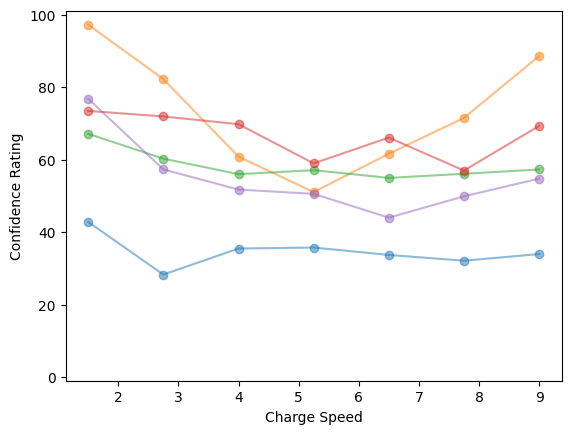

In [14]:
for id in ids:
    df = experiment_df[experiment_df['id'] == id]
    mean_rating_per_speed = pd.DataFrame(df.groupby('chargeSpeed')['confidence'].mean().reset_index())
    plt.plot(mean_rating_per_speed['chargeSpeed'], mean_rating_per_speed['confidence'], marker='o', alpha=0.5)
    plt.ylim(-1, 101)
    plt.xlabel('Charge Speed')
    plt.ylabel('Confidence Rating')

Text(0, 0.5, 'Confidence Rating')

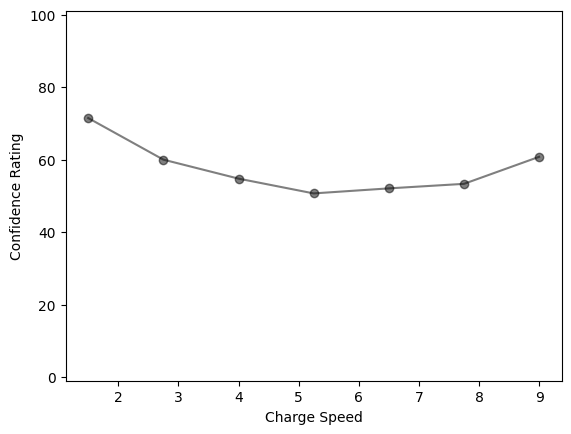

In [15]:
mean_confidence = pd.DataFrame(experiment_df.groupby('chargeSpeed')['confidence'].mean().reset_index())
plt.plot(mean_confidence['chargeSpeed'], mean_confidence['confidence'], color='black', marker='o', alpha=0.5)
plt.ylim(-1, 101)
plt.xlabel('Charge Speed')
plt.ylabel('Confidence Rating')

# main analysis - within sound conditions

## ISI check

In [16]:
isi = pd.DataFrame(experiment_df.groupby(['id', 'soundCondition'])['ISI_ms'].mean()).reset_index()
aov = pg.rm_anova(data=isi, dv='ISI_ms', within='soundCondition', subject='id')
print(aov)

           Source  ddof1  ddof2         F     p-unc  p-GG-corr       ng2  \
0  soundCondition      2      8  0.078429  0.925269   0.803668  0.004084   

        eps  sphericity   W-spher   p-spher  
0  0.523485       False  0.089725  0.026876  


## judgement

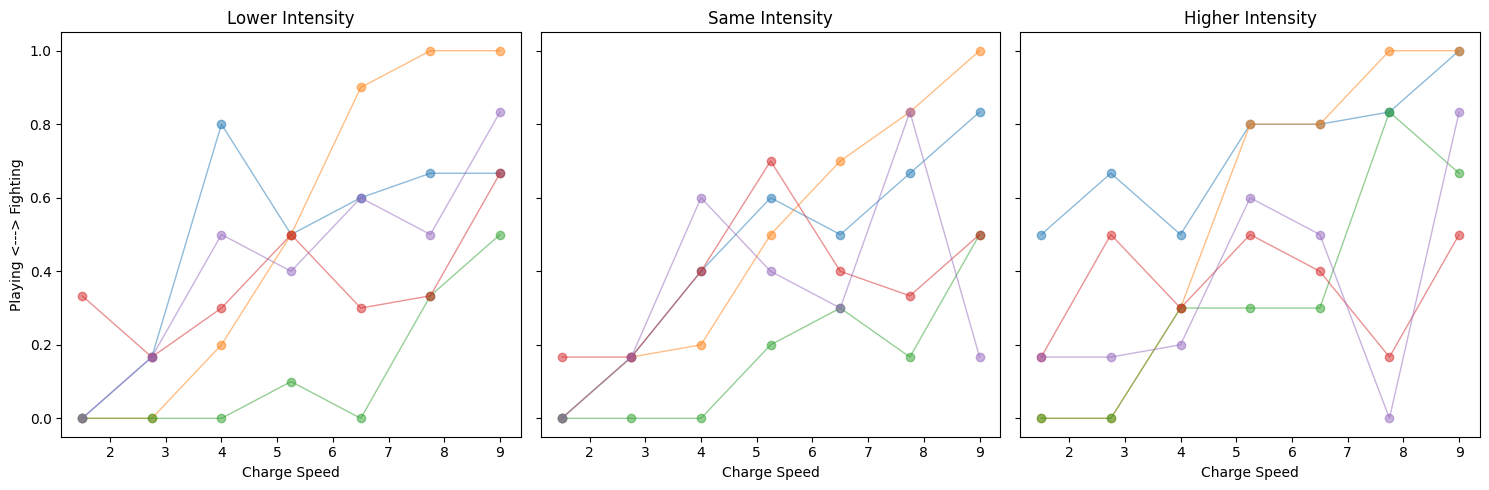

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

conditions = [
    ('lower',  'Lower Intensity',  'o'),
    ('same',   'Same Intensity',   'o'),
    ('higher', 'Higher Intensity', 'o'),
]

for ax, (cond, title, marker) in zip(axes, conditions):
    sub = experiment_df[experiment_df['soundCondition'] == cond]

    # One line per participant
    for pid in ids:
        p = sub[sub['id'] == pid]
        means = p.groupby('chargeSpeed')['is_fight'].mean().reset_index()
        ax.plot(means['chargeSpeed'], means['is_fight'],
                marker=marker, alpha=0.5, linewidth=1)

    ax.set_title(title)
    ax.set_xlabel('Charge Speed')


axes[0].set_ylabel('Playing <---> Fighting')
plt.tight_layout()
plt.show()

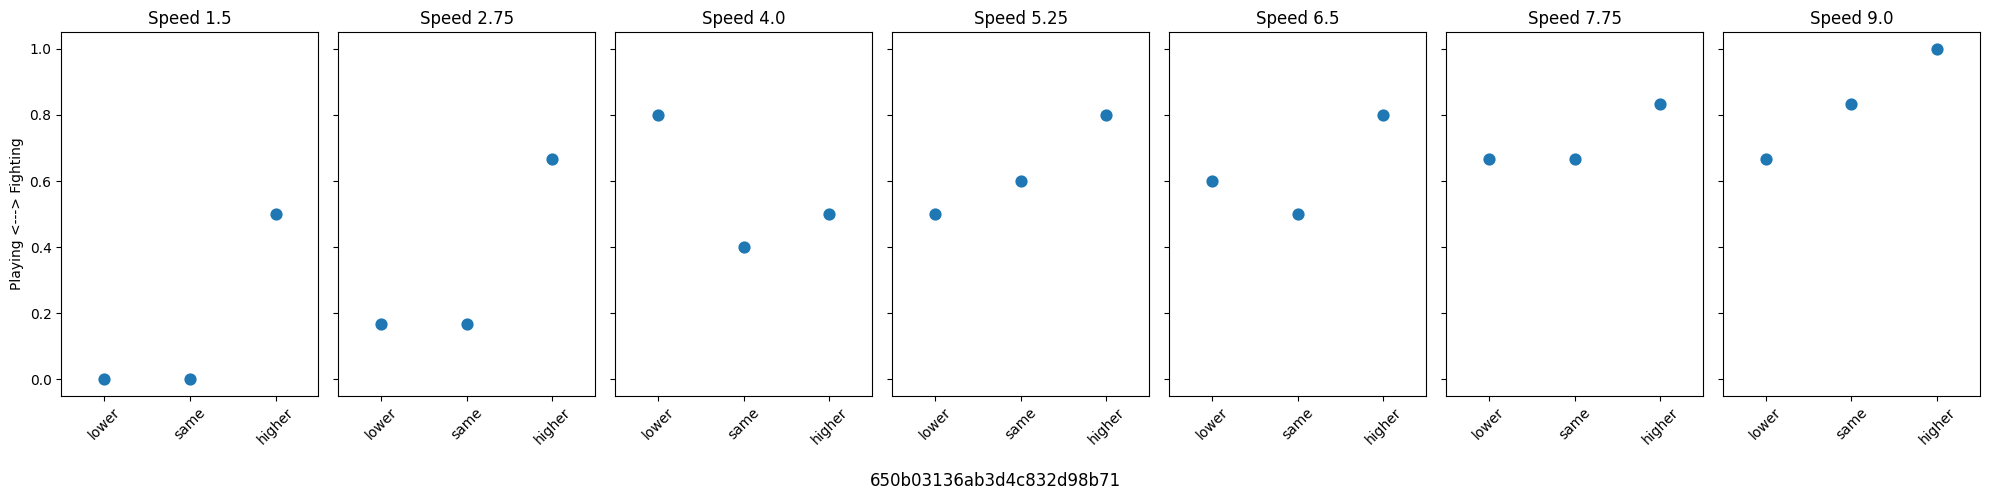

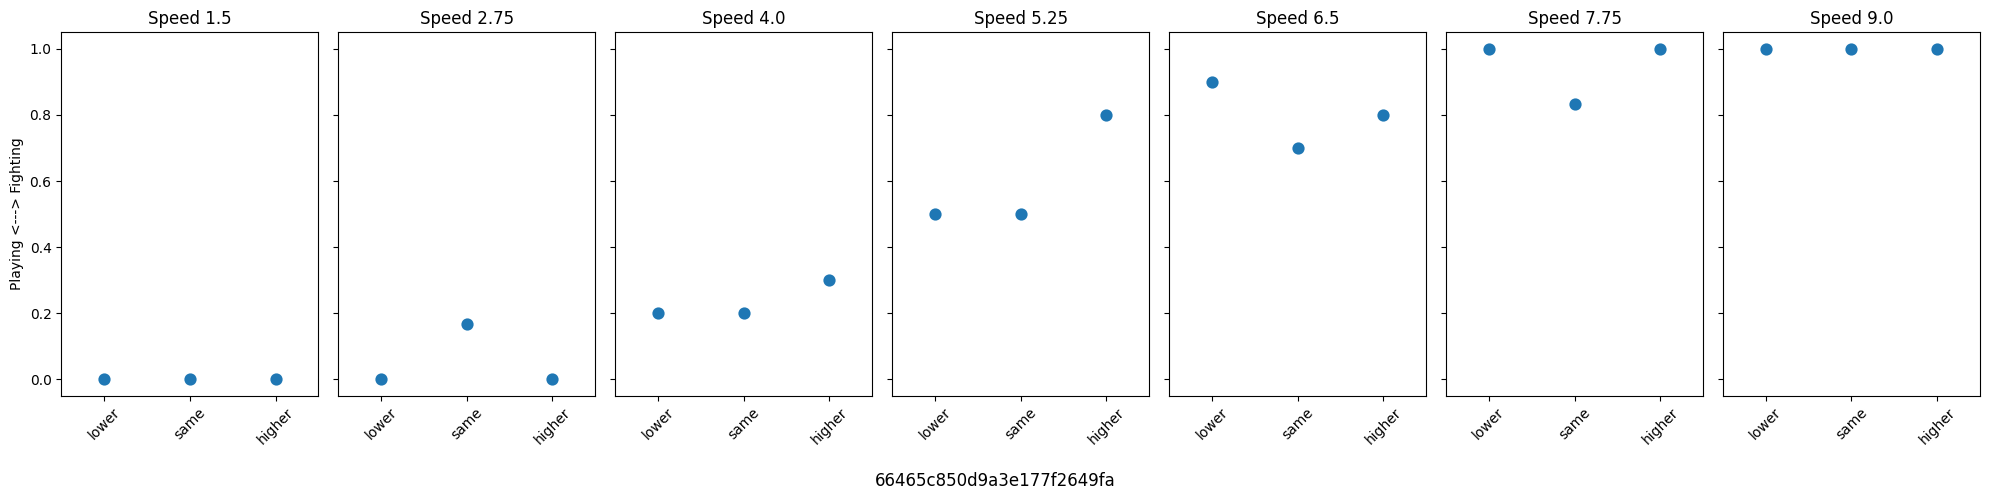

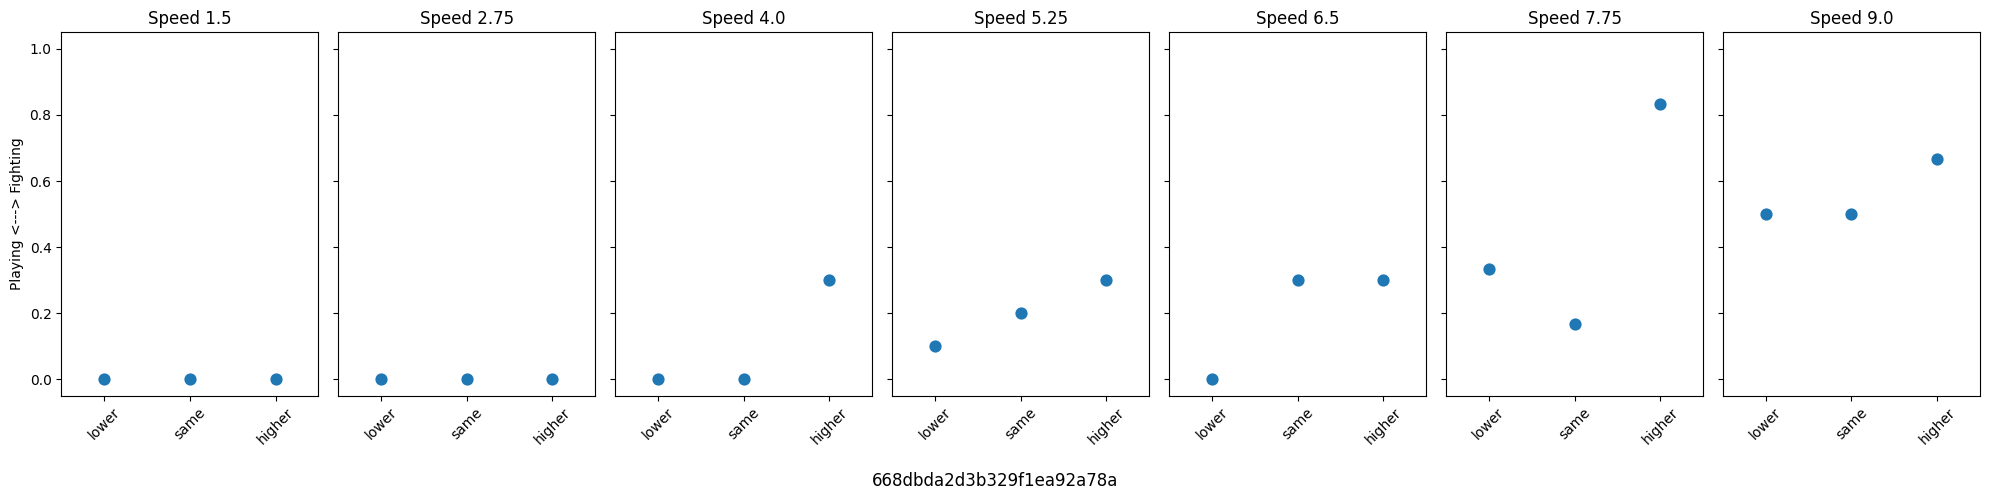

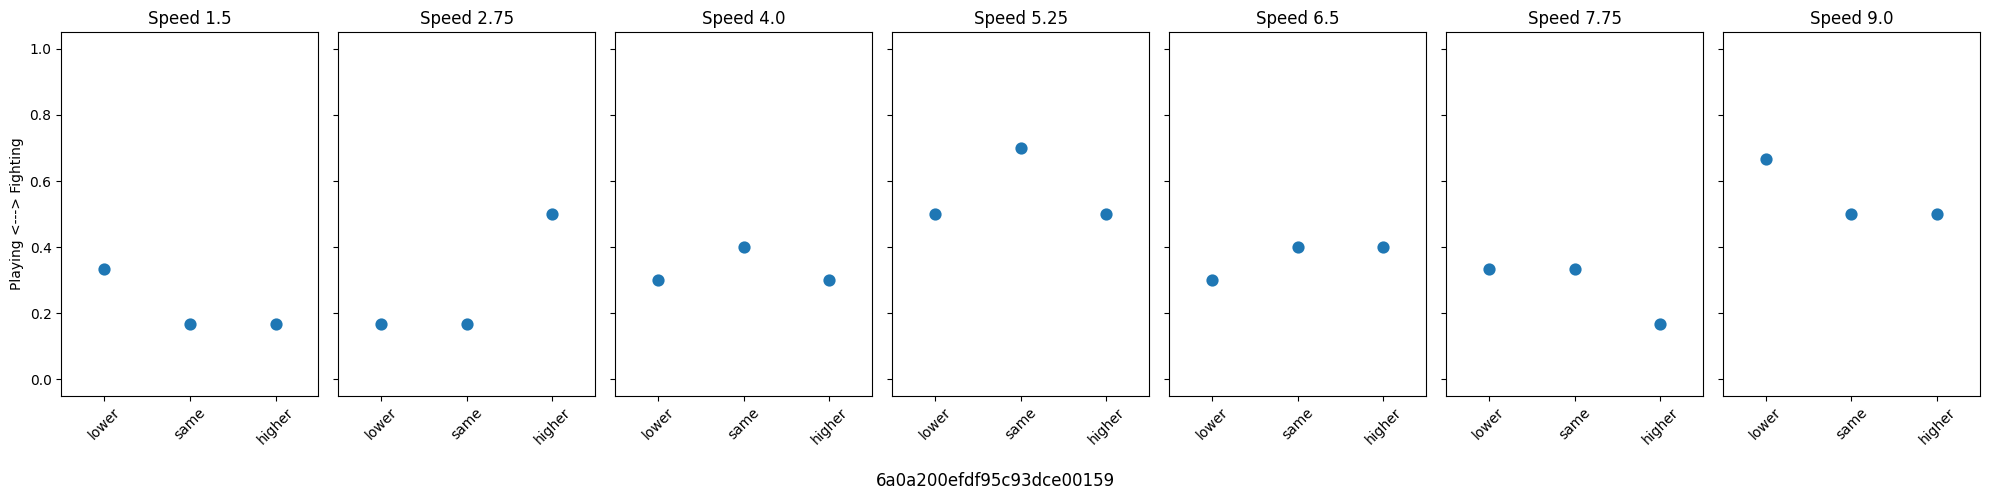

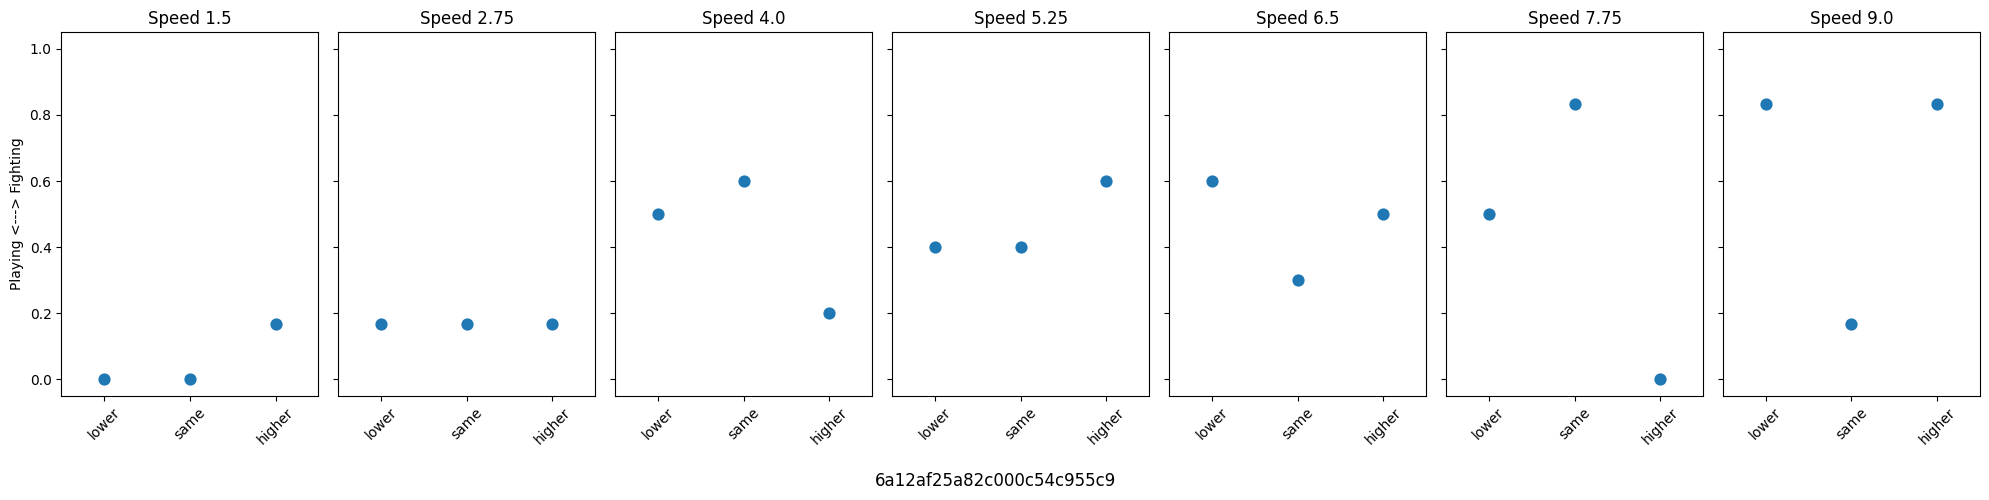

In [18]:
per_pid = (experiment_df
           .groupby(['id', 'soundCondition', 'chargeSpeed'])['is_fight']
           .mean()
           .reset_index())

order = ['lower', 'same', 'higher']
speeds = sorted(per_pid['chargeSpeed'].unique())
ids = per_pid['id'].unique()

for pid in ids:
    pdat = per_pid[per_pid['id'] == pid]
    fig, axes = plt.subplots(1, len(speeds), figsize=(20, 5), sharey=True)

    for ax, speed in zip(axes, speeds):
        sub = pdat[pdat['chargeSpeed'] == speed]
        sns.pointplot(data=sub, x='soundCondition', y='is_fight',
                      order=order, ax=ax, join=False, color='tab:blue')
        ax.set_title(f'Speed {speed}')
        ax.set_xlabel('')
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(axis='x', rotation=45)

    axes[0].set_ylabel('Playing <---> Fighting')
    fig.supxlabel(pid)
    plt.tight_layout()
    plt.show()

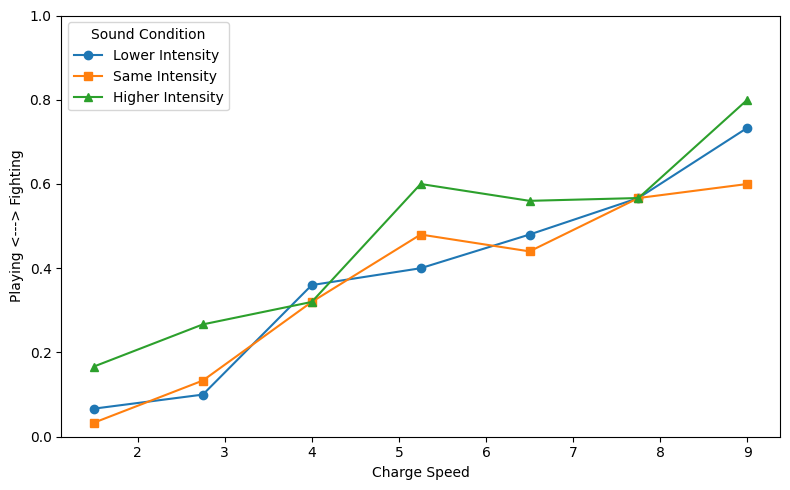

In [19]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Intensity',  'o'),
    ('same',   'Same Intensity',   's'),
    ('higher', 'Higher Intensity', '^'),
]

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['is_fight'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['is_fight'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Playing <---> Fighting')
ax.set_ylim(0, 1)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

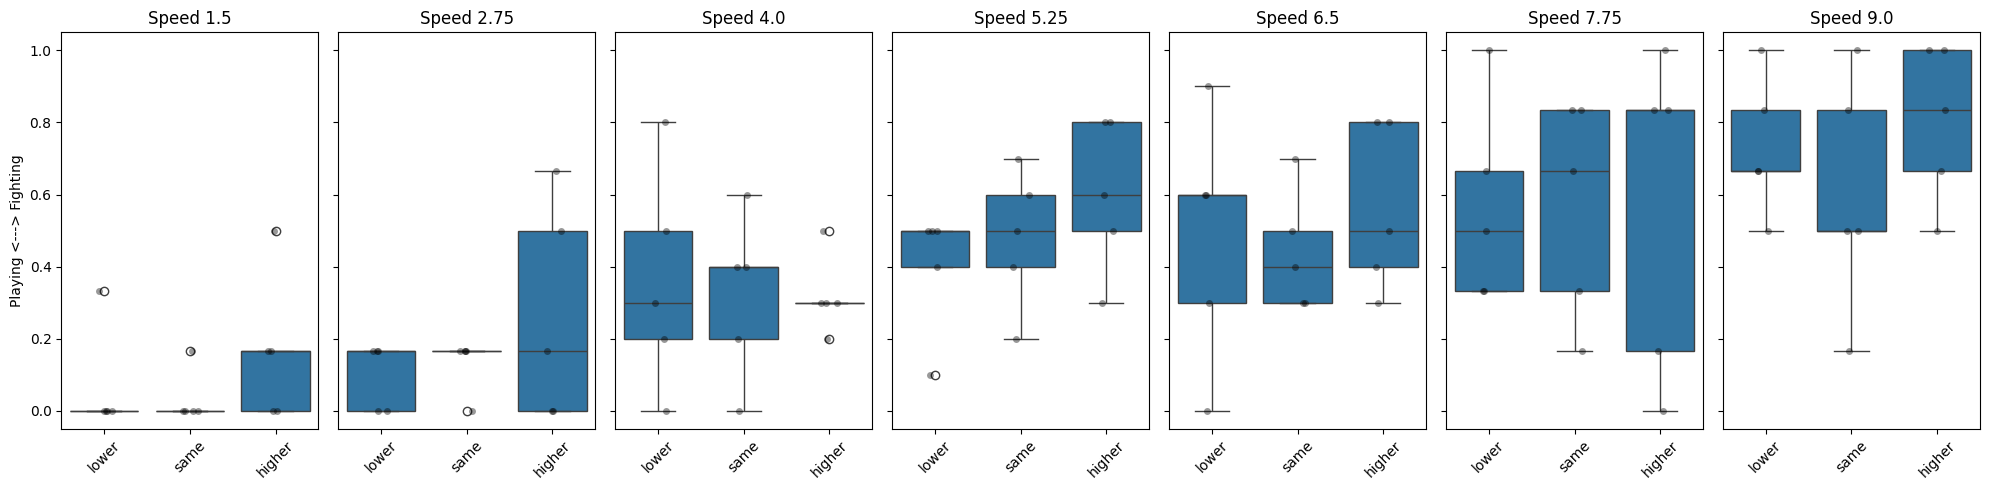

In [20]:
per_pid = (experiment_df
           .groupby(['id', 'soundCondition', 'chargeSpeed'])['is_fight']
           .mean()
           .reset_index())

order = ['lower', 'same', 'higher']
speeds = sorted(per_pid['chargeSpeed'].unique())

fig, axes = plt.subplots(1, len(speeds), figsize=(20, 5), sharey=True)

for ax, speed in zip(axes, speeds):
    sub = per_pid[per_pid['chargeSpeed'] == speed]
    sns.boxplot(data=sub, x='soundCondition', y='is_fight', order=order, ax=ax)
    sns.stripplot(data=sub, x='soundCondition', y='is_fight',
                  order=order, ax=ax, color='black', alpha=0.4, jitter=True)
    ax.set_title(f'Speed {speed}')
    ax.set_xlabel('')
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Playing <---> Fighting')
plt.tight_layout()
plt.show()

## confidence

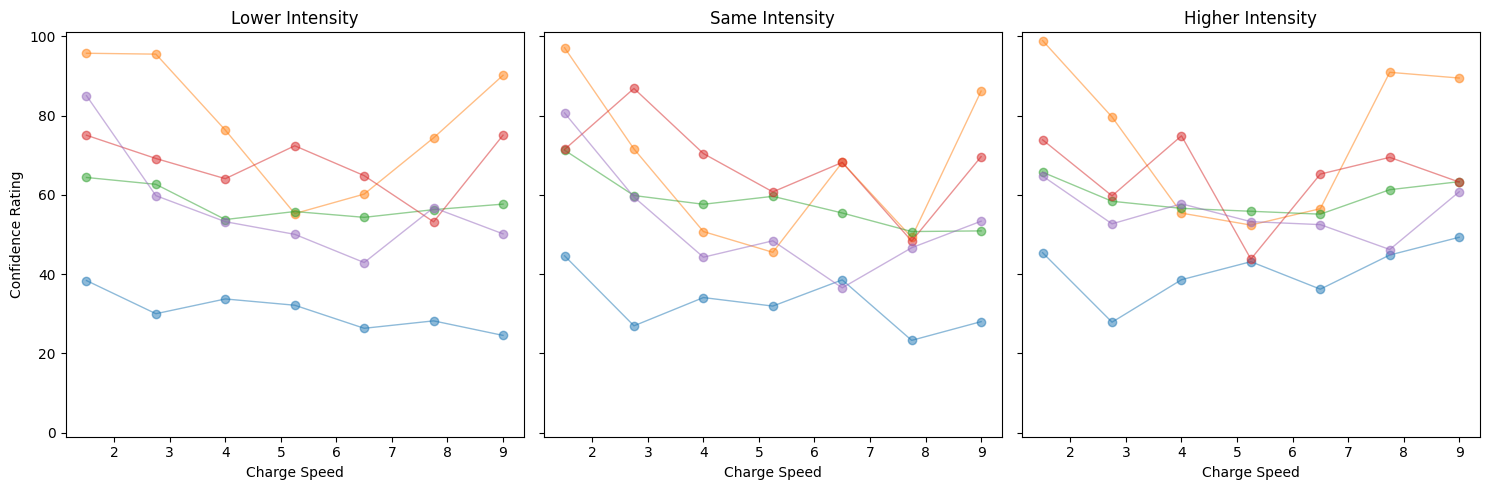

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

conditions = [
    ('lower',  'Lower Intensity',  'o'),
    ('same',   'Same Intensity',   'o'),
    ('higher', 'Higher Intensity', 'o'),
]

for ax, (cond, title, marker) in zip(axes, conditions):
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    for pid in ids:
        p = sub[sub['id'] == pid]
        means = p.groupby('chargeSpeed')['confidence'].mean().reset_index()
        ax.plot(means['chargeSpeed'], means['confidence'],
                marker=marker, alpha=0.5, linewidth=1)

    ax.set_title(title)
    ax.set_xlabel('Charge Speed')
    ax.set_ylim(-1, 101)


axes[0].set_ylabel('Confidence Rating')
plt.tight_layout()
plt.show()

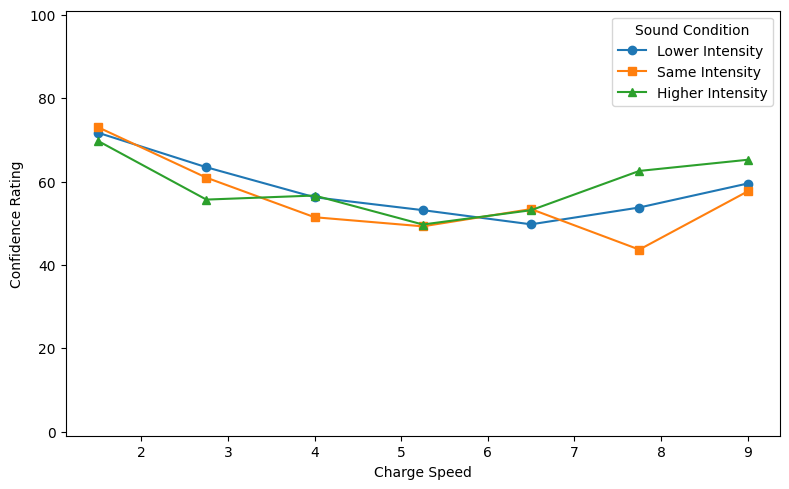

In [22]:
pythonfig, ax = plt.subplots(figsize=(8, 5))

conditions = [
    ('lower',  'Lower Intensity',  'o'),
    ('same',   'Same Intensity',   's'),
    ('higher', 'Higher Intensity', '^'),
]

for cond, label, marker in conditions:
    sub = experiment_df[experiment_df['soundCondition'] == cond]
    means = sub.groupby('chargeSpeed')['confidence'].mean().reset_index()
    ax.plot(means['chargeSpeed'], means['confidence'],
            marker=marker, label=label)

ax.set_xlabel('Charge Speed')
ax.set_ylabel('Confidence Rating')
ax.set_ylim(-1, 101)
ax.legend(title='Sound Condition')
plt.tight_layout()
plt.show()

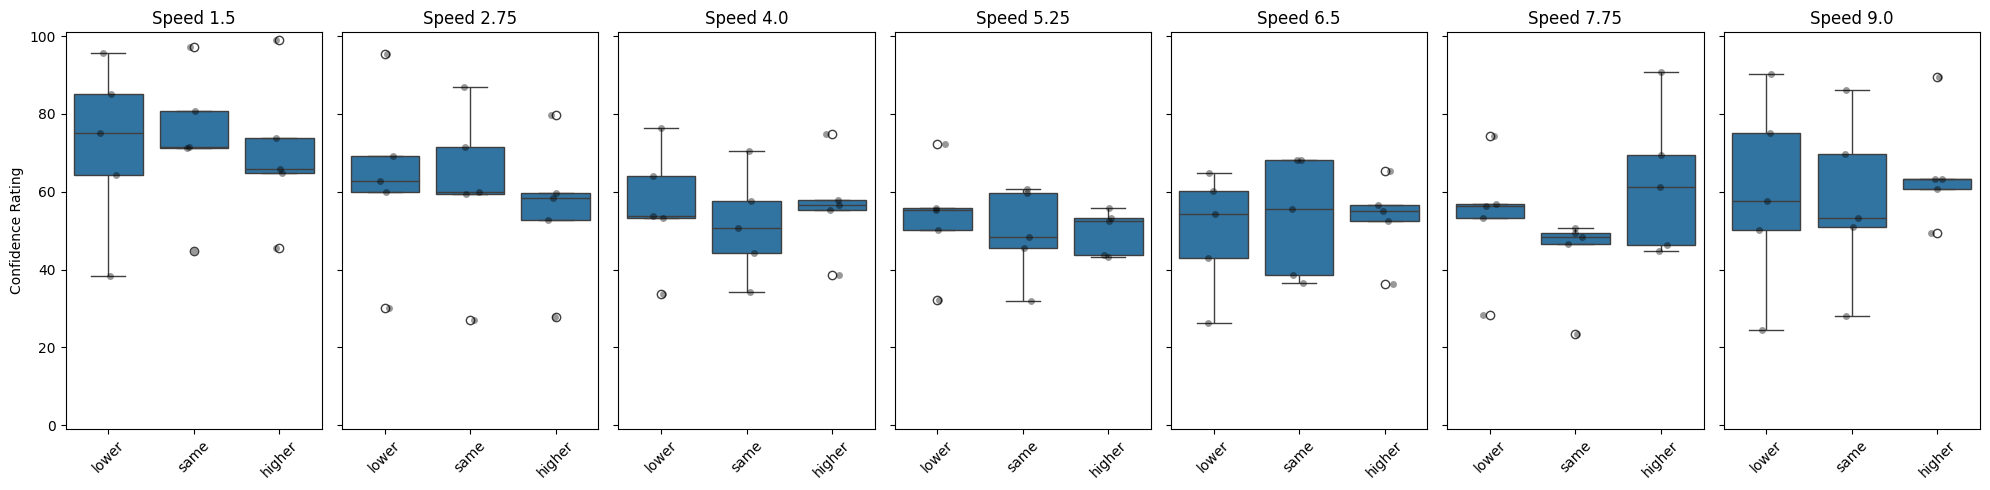

In [23]:
per_pid = (experiment_df
           .groupby(['id', 'soundCondition', 'chargeSpeed'])['confidence']
           .mean()
           .reset_index())

order = ['lower', 'same', 'higher']
speeds = sorted(per_pid['chargeSpeed'].unique())

fig, axes = plt.subplots(1, len(speeds), figsize=(20, 5), sharey=True)

for ax, speed in zip(axes, speeds):
    sub = per_pid[per_pid['chargeSpeed'] == speed]
    sns.boxplot(data=sub, x='soundCondition', y='confidence', order=order, ax=ax)
    sns.stripplot(data=sub, x='soundCondition', y='confidence',
                  order=order, ax=ax, color='black', alpha=0.4, jitter=True)
    ax.set_title(f'Speed {speed}')
    ax.set_xlabel('')
    ax.set_ylim(-1, 101)
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Confidence Rating')
plt.tight_layout()
plt.show()